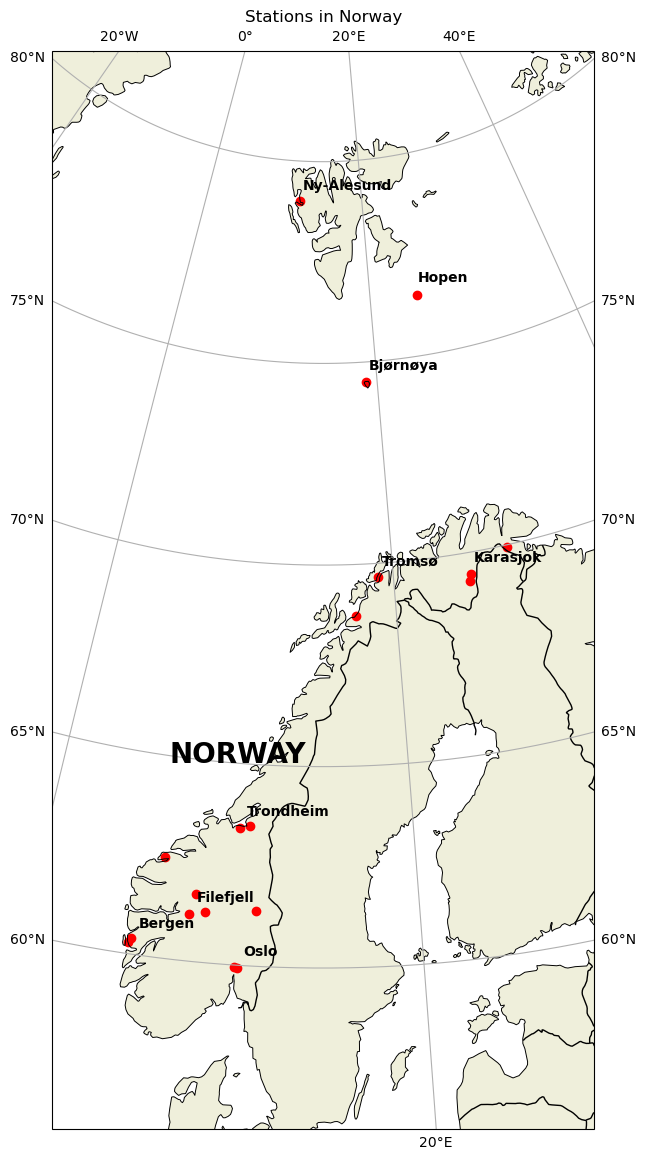

In [36]:
#%pip install cartopy
# use env base

import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Les inn filen 
df = pd.read_csv("sites.dat", sep=r"\s+", encoding="latin-1")

# Use UTM Zone 33N projection for Norway - gives a tall, narrow appearance
proj = ccrs.UTM(33)
data_crs = ccrs.PlateCarree()  # Coordinate system of your data

fig = plt.figure(figsize=(8, 14))
ax = plt.axes(projection=proj)

# Utsnitt som dekker Norge + Svalbard + Jan Mayen (71°N, -8°E)
ax.set_extent([-10, 35, 56, 82], crs=data_crs)

# Land + kystlinjer + landegrenser
ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor='black')
ax.gridlines(draw_labels=True)

# Plott stasjoner med røde sirkler
ax.scatter(df["longitude"], df["latitude"],
           transform=data_crs, marker="o", color="red")

# Vis bare utvalgte stasjonsnavn
selected_stations = ["Oslo", "Bergen", "Trondheim", "Tromsø", "Bjørnøya", "Hopen", "Filefjell", "Karasjok", "Ny-Ålesund"]

for _, row in df.iterrows():
    station_name = row["station"]
    if station_name in selected_stations:
        ax.text(row["longitude"] + 0.3, row["latitude"] + 0.3,
                station_name, transform=data_crs, fontsize=10, 
                fontweight='bold', ha='left')

# Legg til "NORWAY" tekst
ax.text(10, 65, "NORWAY", transform=data_crs, fontsize=20, 
        fontweight='bold', ha='center')

plt.title("Stations in Norway")

# Save figure as PNG
plt.savefig("norway_stations_map.png", dpi=300, bbox_inches='tight')

plt.show()